In [1]:
###
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import RandomOverSampler
# import tensorflow as tf
import shutil
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time
import h5py
import cv2
pd.set_option('display.max_columns', None)

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# !pip install "numpy<2"

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
print(os.listdir())

['.config', 'drive', 'sample_data']


In [6]:
os.chdir('/content/drive/My Drive/CS7643_project')

In [7]:
#!unzip -q "archive.zip" -d "/content/drive/My Drive/7643_finalproject02192025/extract"

# New Section

In [8]:
# os.chdir('/content/drive/My Drive/7643_finalproject02192025/extract') ## small data is in extract

In [9]:
metadata = pd.read_csv(r"MNIST-HAM10000/HAM10000_metadata.csv")
print(metadata.head())
print(metadata.shape)

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
(10015, 7)


In [10]:
print(metadata.dx.unique())
print(metadata.dx_type.unique())

['bkl' 'nv' 'df' 'mel' 'vasc' 'bcc' 'akiec']
['histo' 'consensus' 'confocal' 'follow_up']


In [11]:
# binary_map = {
#     "nv": "benign",
#     "bkl":"benign",
#     "df": "benign",
#     "vasc": "benign",
#     "mel": "Not Benign",
#     "bcc":  "Not Benign",
#     "akiec":  "Not Benign"
# }

binary_map = {
    "nv": 0,
    "bkl": 0,
    "df": 0,
    "vasc": 0,
    "mel": 1,
    "bcc":  1,
    "akiec": 1
}

metadata["target"] = metadata["dx"].map(binary_map)

In [12]:
print(metadata.target.unique())

[0 1]


In [13]:
lesion_counts = metadata['lesion_id'].value_counts()
metadata['duplicates'] = metadata['lesion_id'].map(lambda x: 'duplicated' if lesion_counts[x] > 1 else 'unduplicated')

In [14]:
print(metadata.head())

     lesion_id      image_id   dx dx_type   age   sex localization  target  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp       0   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp       0   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp       0   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp       0   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear       0   

   duplicates  
0  duplicated  
1  duplicated  
2  duplicated  
3  duplicated  
4  duplicated  


In [15]:
## randomly select one image_id for the duplicated ids, if not duplicated, just select the unique one
metadata_unique = metadata.groupby('lesion_id').sample(n=1, random_state=42).reset_index(drop=True)

#metadata_unique = metadata[metadata['duplicates'] == 'unduplicated'].reset_index()
#metadata_unique.drop(['index'], axis=1, inplace=True)

In [16]:

print(metadata_unique.shape)

(7470, 9)


In [17]:
# image_dirs = ['HAM10000_images_part_1', 'HAM10000_images_part_2',
#               'ham10000_images_part_1', 'ham10000_images_part_2']
# merged_image_dir = 'all_images'
# os.makedirs(merged_image_dir, exist_ok=True)

In [18]:


# for img_dir in image_dirs:
#     for fname in os.listdir(img_dir):
#         src = os.path.join(img_dir, fname)
#         dst = os.path.join(merged_image_dir, fname)
#         if not os.path.exists(dst):
#             shutil.copyfile(src, dst)

In [19]:
metadata = metadata_unique

In [20]:
print(metadata.shape)

(7470, 9)


In [21]:
base_dir = r"MNIST-HAM10000/"
metadata['image_path'] = metadata['image_id'] + '.jpg'
metadata['image_folder'] = np.where(metadata['image_id'].str.slice(start=6, stop=12).astype(int)>29305, \
                            'HAM10000_images_part_2/', 'HAM10000_images_part_1/')
metadata['full_path'] = (base_dir + metadata['image_folder'] + metadata['image_path'])
##train_val_df, test_df = train_test_split(metadata, test_size=0.2, stratify=metadata['dx'], random_state=42)
##train_df, val_df = train_test_split(train_val_df, test_size=0.2, stratify=train_val_df['dx'], random_state=42)

In [22]:
train_val_df, test_df = train_test_split(metadata, test_size=0.2, stratify=metadata['target'], random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.2, stratify=train_val_df['target'], random_state=42)

In [23]:
print(os.getcwd())

/content/drive/My Drive/CS7643_project


In [24]:
print(train_val_df.head())
print(train_val_df['target'].unique())

        lesion_id      image_id   dx    dx_type   age     sex  \
2771  HAM_0002792  ISIC_0033169  bkl  consensus  80.0  female   
2938  HAM_0002962  ISIC_0028331  bkl  consensus  80.0    male   
6173  HAM_0006285  ISIC_0030596   nv  follow_up  50.0    male   
5584  HAM_0005672  ISIC_0028388  bkl      histo  50.0  female   
6666  HAM_0006793  ISIC_0030796   nv      histo  60.0  female   

         localization  target    duplicates        image_path  \
2771             back       0  unduplicated  ISIC_0033169.jpg   
2938             back       0  unduplicated  ISIC_0028331.jpg   
6173  upper extremity       0  unduplicated  ISIC_0030596.jpg   
5584             face       0    duplicated  ISIC_0028388.jpg   
6666             back       0  unduplicated  ISIC_0030796.jpg   

                 image_folder  \
2771  HAM10000_images_part_2/   
2938  HAM10000_images_part_1/   
6173  HAM10000_images_part_2/   
5584  HAM10000_images_part_1/   
6666  HAM10000_images_part_2/   

                   

In [25]:
# def copy_images(df, target_root):
#     for _, row in df.iterrows():
#         #class_dir = os.path.join(target_root,(row['dx']))
#         class_dir = os.path.join(target_root,(row['target']))
#         os.makedirs(class_dir, exist_ok=True)
#         shutil.copyfile(row['full_path'], os.path.join(class_dir, row['image_path']))

# # Create base folders
# os.makedirs('data/train', exist_ok=True)
# os.makedirs('data/val', exist_ok=True)
# os.makedirs('data/test', exist_ok=True)

# copy_images(train_df, 'data/train')
# copy_images(val_df, 'data/val')
# copy_images(test_df, 'data/test') ## only takes 1m 1s

In [26]:
IMG_SIZE = (139, 139)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# Transforms for validation & test (no augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

In [27]:
class HAMDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.classes = sorted(self.df['target'].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['full_path']).convert('RGB')
        label = self.class_to_idx[row['target']]
        if self.transform:
            image = self.transform(image)
        return image, label

In [28]:
train_dataset = HAMDataset(train_df, transform=train_transforms)
val_dataset = HAMDataset(val_df, transform=val_test_transforms)
test_dataset = HAMDataset(test_df, transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [29]:
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

# Move batch to GPU
images = images.to(device)
labels = labels.to(device)
print("On device:", images.device)

Image batch shape: torch.Size([32, 3, 139, 139])
Label batch shape: torch.Size([32])
On device: cuda:0


In [30]:
# Load pretrained ResNet101
model = models.resnet101(pretrained=True)

# Optionally freeze all layers (for transfer learning)
for param in model.parameters():
    param.requires_grad = False

# Replace the final FC layer
num_classes = len(train_dataset.classes)  # Should be 7 for HAM10000
model.fc = nn.Linear(model.fc.in_features, num_classes)

# Unfreeze the last ResNet block + FC for fine-tuning
for name, param in model.named_parameters():
    if "layer4" in name or "fc" in name:
        param.requires_grad = True

# Move model to GPU
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet101-63fe2227.pth" to /root/.cache/torch/hub/checkpoints/resnet101-63fe2227.pth
100%|██████████| 171M/171M [00:00<00:00, 201MB/s]


In [31]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

In [32]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [33]:
start_time = time.perf_counter()
EPOCHS = 50

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    print(f"Epoch {epoch+1} | Loss: {running_loss/len(train_loader):.4f} | Accuracy: {100 * correct / total:.2f}%")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")

Epoch 1/50:   0%|          | 0/150 [00:07<?, ?it/s]


KeyboardInterrupt: 

In [29]:
model.eval()
val_correct = 0
val_total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        val_total += labels.size(0)
        val_correct += (predicted == labels).sum().item()

print(f"Validation Accuracy: {100 * val_correct / val_total:.2f}%")

Validation Accuracy: 89.80%


In [ ]:
############## add metadata #####################

In [30]:
print(metadata.isnull().sum())

lesion_id        0
image_id         0
dx               0
dx_type          0
age             52
sex              0
localization     0
target           0
duplicates       0
image_path       0
image_folder     0
full_path        0
dtype: int64


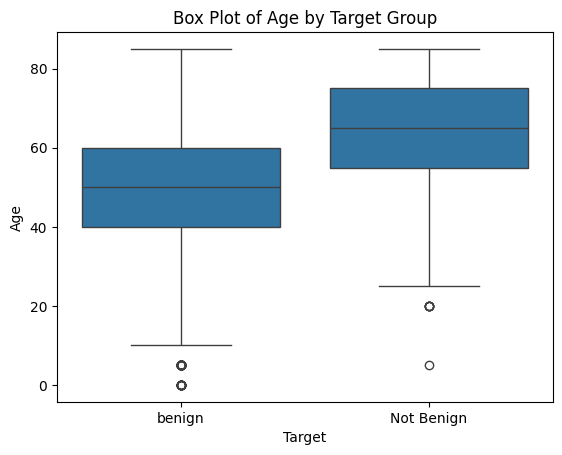

In [31]:
sns.boxplot(x='target', y='age', data=metadata)
plt.title('Box Plot of Age by Target Group')
plt.xlabel('Target')
plt.ylabel('Age')
plt.show()

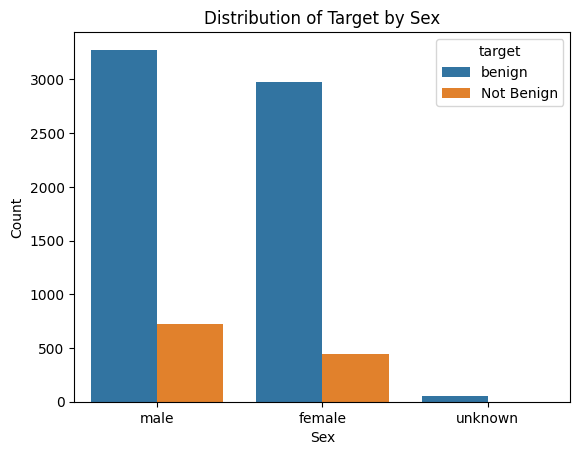

In [32]:
sns.countplot(data=metadata, x='sex', hue='target')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Distribution of Target by Sex')
plt.show()

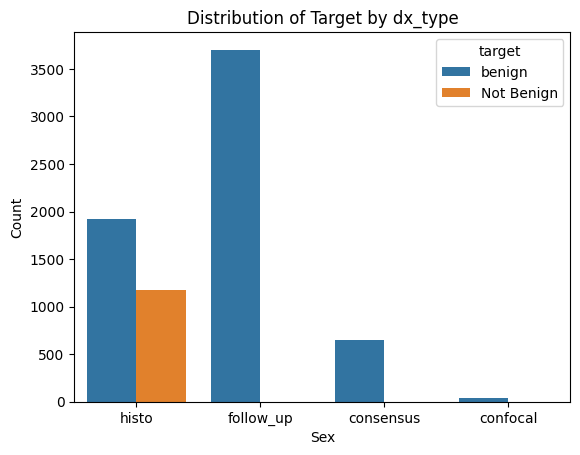

In [33]:
sns.countplot(data=metadata, x='dx_type', hue='target')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Distribution of Target by dx_type')
plt.show()

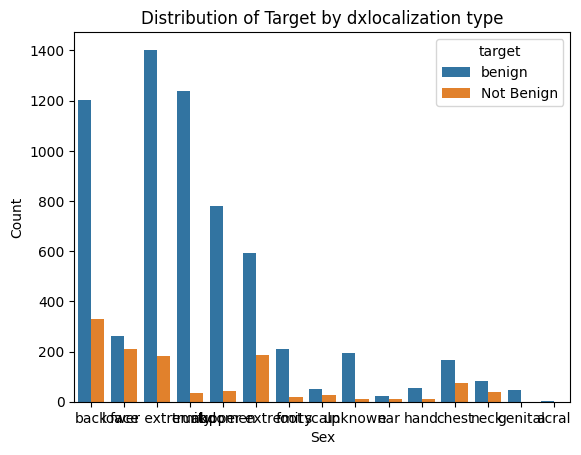

In [34]:
sns.countplot(data=metadata, x='localization', hue='target')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Distribution of Target by dxlocalization type')
plt.show()

In [34]:
metadata['age'] = metadata['age'].fillna(metadata['age'].median())
df_encoded = pd.get_dummies(metadata[['age', 'sex', 'localization']])

In [35]:
class HAMDataset(Dataset):
    def __init__(self, df, meta_array, transform=None):
        self.df = df.reset_index(drop=True)
        self.meta_array = meta_array
        self.transform = transform
        self.classes = sorted(self.df['target'].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['full_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
        label = self.class_to_idx[row['target']]
        return image, meta_features, label


In [36]:
from sklearn.preprocessing import StandardScaler

metadata['age'] = metadata['age'].fillna(metadata['age'].median())
metadata['sex'] = metadata['sex'].fillna('unknown')
metadata['localization'] = metadata['localization'].fillna('unknown')
meta_raw = metadata[['age', 'sex', 'localization']].copy()
meta_encoded = pd.get_dummies(meta_raw, columns=['sex', 'localization'])
scaler = StandardScaler()
meta_encoded['age'] = scaler.fit_transform(meta_encoded[['age']])

In [37]:
meta_encoded = meta_encoded.set_index(metadata.index)

# Select metadata rows for each split and convert
train_meta = torch.tensor(meta_encoded.loc[train_df.index].to_numpy().astype(np.float32))
val_meta   = torch.tensor(meta_encoded.loc[val_df.index].to_numpy().astype(np.float32))
test_meta  = torch.tensor(meta_encoded.loc[test_df.index].to_numpy().astype(np.float32))

In [38]:
train_dataset = HAMDataset(train_df, meta_array=train_meta, transform=train_transforms)
val_dataset   = HAMDataset(val_df, meta_array=val_meta, transform=val_test_transforms)
test_dataset  = HAMDataset(test_df, meta_array=test_meta, transform=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [39]:
def __getitem__(self, idx):
    row = self.metadata.iloc[idx]

    image = Image.open(row['full_path']).convert('RGB')
    if self.transform:
        image = self.transform(image)

    meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)
    label = self.class_to_idx[row['target']]

    return image, meta_features, label


In [40]:
class ResNetWithMetadata(nn.Module):
    def __init__(self, num_metadata_features, num_classes, freeze):
        super(ResNetWithMetadata, self).__init__()

        # Load pretrained ResNet101
        self.resnet = models.resnet101(pretrained=True)

        # Replace ResNet's classification head with identity
        self.resnet.fc = nn.Identity()

        # Metadata MLP with BatchNorm
        self.meta_fc = nn.Sequential(
            nn.Linear(num_metadata_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )

        # Optional: Gating mechanism to balance image vs metadata features
        self.gate = nn.Sequential(
            nn.Linear(2048 + 32, 1),
            nn.Sigmoid()
        )

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Linear(2048 + 32, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

        # Unfreeze only the classifying blocks for fine-tuning
        if freeze == True:
          for name, param in self.resnet.named_parameters():
              if ("meta_fc" in name) or ("classifier" in name) or ("meta_fc" in name):
                param.requires_grad = True
              else:
                param.requires_grad =  False
        else:
          for name, param in self.resnet.named_parameters():
              param.requires_grad = True

    def forward(self, image, metadata):
        # Extract features
        image_features = self.resnet(image)              # [batch, 2048]
        metadata_features = self.meta_fc(metadata)       # [batch, 32]

        # Concatenate both
        combined = torch.cat((image_features, metadata_features), dim=1)  # [batch, 2080]

        # Apply gating (optional attention-like weighting)
        gate_value = self.gate(combined)                 # [batch, 1]
        combined = gate_value * combined                 # scaled features

        # Final classification
        output = self.classifier(combined)
        return output

In [41]:
num_metadata_features = train_meta.shape[1]
num_classes = len(train_dataset.classes)
model = ResNetWithMetadata(num_metadata_features=num_metadata_features,num_classes=num_classes, freeze=False).to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [42]:
# import torch.optim as optim

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        Focal Loss for classification tasks.
        Args:
            alpha (tensor): class weights (shape: [num_classes])
            gamma (float): focusing parameter
            reduction (str): 'mean', 'sum', or 'none'
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss


In [44]:
class_count = metadata['target'].value_counts()
class_ratio = class_count[0]/class_count[1]*0.8
class_weights = torch.tensor([1.0, class_ratio], dtype=torch.float32).to(device)
criterion = FocalLoss(alpha=class_weights, gamma=2).to(device)

In [45]:
from tqdm import tqdm
from sklearn.metrics import f1_score, roc_auc_score, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim

In [46]:
EPOCHS = 50
save_path = 'best_model_unfreeze.pth'
best_f1 = 0
optimizer = optim.Adam(model.parameters(), lr=5e-5)

In [47]:
def evaluate_model(model, dataloader, device):
    model.eval()
    total = 0
    correct = 0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, metadata, labels in dataloader:
            images = images.to(device)
            metadata = metadata.to(device)
            labels = labels.to(device)

            outputs = model(images, metadata)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(probs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"✅ Eval Accuracy: {accuracy:.2f}%")
    return all_preds, all_labels, all_probs

In [293]:
start_time = time.perf_counter()
for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{EPOCHS}")

    for images, metadata, labels in loop:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images, metadata)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    # 🎯 Training summary
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    print(f"✅ Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    # 🧪 VALIDATION
    val_preds, val_labels, val_probs = evaluate_model(model, val_loader, device)

    f1 = f1_score(val_labels, val_preds)
    auc = roc_auc_score(val_labels, val_probs)
    cm = confusion_matrix(val_labels, val_preds)

    print(f"📊 Validation F1 Score: {f1:.4f}")
    print(f"📈 Validation AUC: {auc:.4f}")
    print(f"🧾 Confusion Matrix:\n{cm}")

    # 💾 Save best model by F1
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), save_path)
        print(f"💾 Saved new best model with F1: {best_f1:.4f}")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")


🚀 Epoch 1/50


Training Epoch 1/50:   0%|          | 0/150 [00:00<?, ?it/s]<ipython-input-280-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 1/50: 100%|██████████| 150/150 [01:04<00:00,  2.31it/s, acc=69.7, loss=0.968]


✅ Training Loss: 0.3591 | Accuracy: 69.67%
✅ Eval Accuracy: 74.33%
📊 Validation F1 Score: 0.5397
📈 Validation AUC: 0.9365
🧾 Confusion Matrix:
[[709 300]
 [  7 180]]
💾 Saved new best model with F1: 0.5397

🚀 Epoch 2/50


Training Epoch 2/50:   0%|          | 0/150 [00:00<?, ?it/s]<ipython-input-280-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 2/50: 100%|██████████| 150/150 [01:09<00:00,  2.15it/s, acc=72.7, loss=0.226]


✅ Training Loss: 0.3014 | Accuracy: 72.72%
✅ Eval Accuracy: 80.18%
📊 Validation F1 Score: 0.5976
📈 Validation AUC: 0.9401
🧾 Confusion Matrix:
[[783 226]
 [ 11 176]]
💾 Saved new best model with F1: 0.5976

🚀 Epoch 3/50


...

✅ Training Loss: 0.1304 | Accuracy: 90.56%
✅ Eval Accuracy: 87.54%
📊 Validation F1 Score: 0.6809
📈 Validation AUC: 0.9434
🧾 Confusion Matrix:
[[888 121]
 [ 28 159]]

🚀 Epoch 49/50


Training Epoch 49/50:   0%|          | 0/150 [00:00<?, ?it/s]<ipython-input-280-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 49/50: 100%|██████████| 150/150 [01:05<00:00,  2.30it/s, acc=91.7, loss=0.11]


✅ Training Loss: 0.1164 | Accuracy: 91.74%
✅ Eval Accuracy: 89.72%
📊 Validation F1 Score: 0.7092
📈 Validation AUC: 0.9293
🧾 Confusion Matrix:
[[923  86]
 [ 37 150]]

🚀 Epoch 50/50


Training Epoch 50/50:   0%|          | 0/150 [00:00<?, ?it/s]<ipython-input-280-b12b39651b23>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 50/50: 100%|██████████| 150/150 [01:04<00:00,  2.31it/s, acc=91, loss=0.725]


✅ Training Loss: 0.1354 | Accuracy: 91.05%
✅ Eval Accuracy: 91.30%
📊 Validation F1 Score: 0.7400
📈 Validation AUC: 0.9366
🧾 Confusion Matrix:
[[944  65]
 [ 39 148]]
💾 Saved new best model with F1: 0.7400
Execution time: 3938.7183 seconds


In [54]:
# After training is done:
val_preds, val_labels = evaluate_model(model, val_loader, device)

# Or for test set
test_preds, test_labels = evaluate_model(model, test_loader, device)

<ipython-input-36-cf70cbb1dcce>:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx], dtype=torch.float32)


✅ Eval Accuracy: 87.12%


ValueError: too many values to unpack (expected 2)

In [45]:
# Print classification report
print(classification_report(val_labels, val_preds, target_names=train_dataset.classes))

# Confusion matrix
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_dataset.classes, yticklabels=train_dataset.classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

NameError: name 'val_labels' is not defined

# Transfer Learning Section

In [140]:
# hdf5 file path
hdf5_path = r"isic-2024-challenge/train-image.hdf5"

# load metadata and map localization column categories
metadata_isic = pd.read_csv(r"isic-2024-challenge/train-metadata.csv")
metadata_isic = metadata_isic[['isic_id', 'patient_id', 'target', 'sex', 'age_approx', 'anatom_site_general']]
metadata_isic.rename(columns = {'age_approx':'age', 'anatom_site_general':'localization'}, inplace=True)
localization_map = {
    "posterior torso": "back",
    "lower extremity":"lower extremity",
    "anterior torso": "trunk",
    "upper extremity": "upper extremity",
    "head/neck": "face"
}

metadata_isic["localization"] = metadata_isic["localization"].map(localization_map)

# remove where metadata not available (we still have a lot of data to train on)
metadata_isic = metadata_isic[~(pd.isnull(metadata_isic['localization']))]
metadata_isic = metadata_isic[~(pd.isnull(metadata_isic['sex']))]
metadata_isic = metadata_isic[~(pd.isnull(metadata_isic['age']))]

# add image data path
base_dir = r"isic-2024-challenge/train-image/image/"
metadata_isic['image_path'] = metadata_isic['isic_id']
metadata_isic['full_path'] = (metadata_isic['image_path'])

# reduce number of rows to keep traiining time reasonale
# meta_isic_encoded = meta_isic_encoded.sample(frac=0.1, random_state=42)
metadata_isic_0 = metadata_isic[metadata_isic['target']==0]
metadata_isic_0 = metadata_isic_0.sample(frac=0.02, random_state=42)
metadata_isic_1 = metadata_isic[metadata_isic['target']==1]
metadata_isic = pd.concat([metadata_isic_0, metadata_isic_1], ignore_index=True)
metadata_isic = metadata_isic.reset_index(drop=True)

# split in training, validation and test and convert to tensor
train_val_isic_df, test_isic_df = train_test_split(metadata_isic, test_size=0.2, stratify=metadata_isic['target'], random_state=42)
train_isic_df, val_isic_df = train_test_split(train_val_isic_df, test_size=0.2, stratify=train_val_isic_df['target'], random_state=42)


<ipython-input-140-b4449f2baa27>:5: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_isic = pd.read_csv(r"isic-2024-challenge/train-metadata.csv")
<ipython-input-140-b4449f2baa27>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata_isic['image_path'] = metadata_isic['isic_id']
<ipython-input-140-b4449f2baa27>:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata_isic['full_path'] = (metadata_isic['image_path'])


In [143]:
# 1-hot encoding + age scaling
meta_raw = metadata_isic[['age', 'sex', 'localization']].copy()
meta_isic_encoded = pd.get_dummies(meta_raw, columns=['sex', 'localization'])
meta_isic_encoded['age'] = scaler.transform(meta_isic_encoded[['age']]) # using same scaler defined on HAM10000 metadata

# no need to do this: the number of meta-features will be different on this dataset and we will fine tune on those
# meta_isic_encoded['sex_unknown'] = False
# meta_isic_cols = [c for c in list(meta_isic_encoded.columns) if 'localization' in c]
# meta_ham_cols = [c for c in list(meta_encoded.columns) if 'localization' in c]
# for c in meta_ham_cols:     # add 1-hot encoded columns not present in new dataset
#   if c not in meta_isic_cols:
#     meta_isic_encoded[c] = False

meta_isic_encoded = meta_isic_encoded.set_index(metadata_isic.index)

In [144]:
# Select metadata rows for each split and convert
train_isic_meta = torch.tensor(meta_isic_encoded.loc[train_isic_df.index].to_numpy().astype(np.float32))
val_isic_meta   = torch.tensor(meta_isic_encoded.loc[val_isic_df.index].to_numpy().astype(np.float32))
test_isic_meta  = torch.tensor(meta_isic_encoded.loc[test_isic_df.index].to_numpy().astype(np.float32))

In [145]:
class ISICDataset(Dataset):
    def __init__(self, df, meta_array, hdf5_path, transform=None):
        self.df = df.reset_index(drop=True)
        self.meta_array = meta_array
        self.transform = transform
        self.hdf5_path = hdf5_path
        self.classes = sorted(self.df['target'].unique())
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # image = Image.open(row['full_path']).convert('RGB')
        with h5py.File(self.hdf5_path, 'r') as hf:
            image = hf[row['full_path']][()]
            # Convert the binary data to a numpy array
            image = np.frombuffer(image, np.uint8)
            image = cv2.cvtColor(cv2.imdecode(image, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
            image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)
        meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
        label = self.class_to_idx[row['target']]
        return image, meta_features, label



In [146]:
IMG_SIZE = (139, 139)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
])

# Transforms for validation & test (no augmentation)
val_test_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

In [149]:
train_dataset_isic = ISICDataset(train_isic_df, meta_array=train_isic_meta, transform=train_transforms, hdf5_path=hdf5_path)
val_dataset_isic   = ISICDataset(val_isic_df, meta_array=val_isic_meta, transform=val_test_transforms, hdf5_path=hdf5_path)
test_dataset_isic  = ISICDataset(test_isic_df, meta_array=test_isic_meta, transform=val_test_transforms, hdf5_path=hdf5_path)

train_loader = DataLoader(train_dataset_isic, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset_isic, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset_isic, batch_size=32, shuffle=False)

In [150]:
class ResNetWithMetadata_FineTune(nn.Module):
    def __init__(self, num_metadata_features, num_classes, freeze, weights_path):
        super(ResNetWithMetadata_FineTune, self).__init__()

        # Load empty ResNet101
        # self.resnet = models.resnet101(pretrained=False)
        self.resnetwithmetadata = ResNetWithMetadata(num_metadata_features=num_metadata_features,num_classes=num_classes, freeze=True)

        # load weights from full training
        self.teacher_dict = torch.load(weights_path)

        # need to remove the meta_fc layer since input size different than teacher model
        self.filtered_state = {k: v for k, v in self.teacher_dict.items() if 'resnet' in k}

        self.resnet_state = self.resnetwithmetadata.resnet.state_dict()
        self.resnet_state.update(self.filtered_state)

        # # Replace ResNet's classification head with identity
        # self.resnetwithmetadata.resnet.fc = nn.Identity()

        # Metadata MLP with BatchNorm
        self.resnetwithmetadata.meta_fc = nn.Sequential(
            nn.Linear(num_metadata_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
        )

        # # Optional: Gating mechanism to balance image vs metadata features
        # self.resnetwithmetadata.gate = nn.Sequential(
        #     nn.Linear(2048 + 32, 1),
        #     nn.Sigmoid()
        # )

        # # Final classifier
        # self.resnetwithmetadata.classifier = nn.Sequential(
        #     nn.Linear(2048 + 32, 128),
        #     nn.ReLU(),
        #     nn.Dropout(0.5),
        #     nn.Linear(128, num_classes)
        # )

        # Unfreeze only the classifying blocks for fine-tuning
        if freeze == True:
          for name, param in self.resnetwithmetadata.named_parameters():
              if ("meta_fc" in name) or ("classifier" in name) or ("gate" in name):
                param.requires_grad = True
              else:
                param.requires_grad =  False
        else:
          for name, param in self.resnetwithmetadata.named_parameters():
              param.requires_grad = True

    def forward(self, image, metadata):
        # Extract features
        image_features = self.resnetwithmetadata.resnet(image)              # [batch, 2048]
        metadata_features = self.resnetwithmetadata.meta_fc(metadata)       # [batch, 32]
        # print('image_features = ' + str(image_features))
        # print('metadata = ' + str(metadata))
        # print('metadata_features = ' + str(metadata_features))

        # Concatenate both
        combined = torch.cat((image_features, metadata_features), dim=1)  # [batch, 2080]
        # print('combined = ' + str(combined))

        # Apply gating (optional attention-like weighting)
        gate_value = self.resnetwithmetadata.gate(combined)                 # [batch, 1]
        combined = gate_value * combined                 # scaled features
        # print('gate value = ' + str(gate_value))


        # Final classification
        output = self.resnetwithmetadata.classifier(combined)
        # print('output = ' + str(output))
        return output

In [151]:
class_count = metadata_isic['target'].value_counts()
class_ratio = class_count[0]/class_count[1]*0.8
# class_ratio = 10
class_weights = torch.tensor([1.0, class_ratio], dtype=torch.float32).to(device)
criterion_isic = FocalLoss(alpha=class_weights, gamma=2).to(device)

In [152]:
weights_path = 'best_model_unfreeze.pth'
num_metadata_features_isic = train_isic_meta.shape[1]
num_classes_isic = len(train_dataset_isic.classes)
model_isic = ResNetWithMetadata_FineTune(num_metadata_features=num_metadata_features_isic,num_classes=num_classes_isic, freeze=True, weights_path = weights_path).to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet101_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [153]:
EPOCHS = 50
save_path = 'best_model_isic_transfer_learning.pth'
best_f1 = 0
optimizer = optim.Adam(model.parameters(), lr=5e-5)

In [ ]:
start_time = time.perf_counter()
for epoch in range(EPOCHS):
    print(f"\n🚀 Epoch {epoch + 1}/{EPOCHS}")
    model_isic.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{EPOCHS}")

    for images, metadata, labels in loop:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model_isic(images, metadata)
        loss = criterion_isic(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    # 🎯 Training summary
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    print(f"✅ Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")

    # 🧪 VALIDATION
    val_preds, val_labels, val_probs = evaluate_model(model_isic, val_loader, device)
    # print(val_preds)
    # print(val_labels)
    # print(val_probs)

    f1 = f1_score(val_labels, val_preds)
    auc = roc_auc_score(val_labels, val_probs)
    cm = confusion_matrix(val_labels, val_preds)

    print(f"📊 Validation F1 Score: {f1:.4f}")
    print(f"📈 Validation AUC: {auc:.4f}")
    print(f"🧾 Confusion Matrix:\n{cm}")

    # 💾 Save best model by F1
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model_isic.state_dict(), save_path)
        print(f"💾 Saved new best model with F1: {best_f1:.4f}")

end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")


🚀 Epoch 1/50


Training Epoch 1/50:   0%|          | 0/161 [00:00<?, ?it/s]<ipython-input-145-87933e78f601>:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 1/50: 100%|██████████| 161/161 [01:26<00:00,  1.86it/s, acc=49.3, loss=0.17]


✅ Training Loss: 0.6943 | Accuracy: 49.33%
✅ Eval Accuracy: 42.59%
📊 Validation F1 Score: 0.0936
📈 Validation AUC: 0.5234
🧾 Confusion Matrix:
[[508 713]
 [ 23  38]]
💾 Saved new best model with F1: 0.0936

🚀 Epoch 2/50


Training Epoch 2/50:   0%|          | 0/161 [00:00<?, ?it/s]<ipython-input-145-87933e78f601>:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 2/50: 100%|██████████| 161/161 [01:24<00:00,  1.91it/s, acc=49.7, loss=0.192]


✅ Training Loss: 0.6965 | Accuracy: 49.72%
✅ Eval Accuracy: 36.35%
📊 Validation F1 Score: 0.0993
📈 Validation AUC: 0.5207
🧾 Confusion Matrix:
[[421 800]
 [ 16  45]]
💾 Saved new best model with F1: 0.0993

🚀 Epoch 3/50


...

Training Epoch 13/50:   0%|          | 0/161 [00:00<?, ?it/s]<ipython-input-145-87933e78f601>:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 13/50: 100%|██████████| 161/161 [01:22<00:00,  1.94it/s, acc=50.6, loss=1.76]


✅ Training Loss: 0.7008 | Accuracy: 50.58%
✅ Eval Accuracy: 42.98%
📊 Validation F1 Score: 0.0942
📈 Validation AUC: 0.5074
🧾 Confusion Matrix:
[[513 708]
 [ 23  38]]

🚀 Epoch 14/50


Training Epoch 14/50:   0%|          | 0/161 [00:00<?, ?it/s]<ipython-input-145-87933e78f601>:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 14/50: 100%|██████████| 161/161 [01:23<00:00,  1.93it/s, acc=50.6, loss=1.71]


✅ Training Loss: 0.6997 | Accuracy: 50.56%
✅ Eval Accuracy: 38.92%
📊 Validation F1 Score: 0.0948
📈 Validation AUC: 0.5202
🧾 Confusion Matrix:
[[458 763]
 [ 20  41]]

🚀 Epoch 15/50


Training Epoch 15/50:   0%|          | 0/161 [00:00<?, ?it/s]<ipython-input-145-87933e78f601>:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  meta_features = torch.tensor(self.meta_array[idx].clone().detach(), dtype=torch.float32)
Training Epoch 15/50:  32%|███▏      | 51/161 [00:26<00:56,  1.94it/s, acc=48.5, loss=1.24]

In [141]:
train_isic_df['target'].value_counts()

,count
target,
0,4883
1,244


In [142]:
val_isic_df['target'].value_counts()

,count
target,
0,1221
1,61
